#Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Load and Explore the Dataset

In [2]:
df = pd.read_csv('youtube_channel_real_performance_analytics.csv')
df.head()

,ID,Video Duration,Video Publish Time,Days Since Publish,Day,Month,Year,Day of Week,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
0,0,201.0,2016-06-02 00:00:00,0,2,6,2016,Thursday,0.024,723.0,...,0.0,0.0,40.38,81.0,23531.0,533.1636,51.0,0.561,41118.0,27.66
1,1,391.0,2016-06-10 00:00:00,8,10,6,2016,Friday,0.056,727.0,...,0.0,0.0,39.85,156.0,11478.0,500.5628,33.0,0.648,41627.0,5.85
2,2,133.0,2016-06-14 00:00:00,4,14,6,2016,Tuesday,0.014,76.0,...,0.0,0.0,30.88,41.0,6153.0,70.7287,8.0,0.089,38713.0,7.07
3,3,14.0,2016-06-29 00:00:00,15,29,6,2016,Wednesday,0.004,18.0,...,0.0,0.0,103.05,14.0,4398.0,17.6251,2.0,0.017,35245.0,5.60
4,4,45.0,2016-07-01 00:00:00,2,1,7,2016,Friday,0.000,0.0,...,0.0,0.0,55.70,25.0,14659.0,104.3341,28.0,0.000,46218.0,8.62


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 70 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ID                                  364 non-null    int64  
 1   Video Duration                      364 non-null    float64
 2   Video Publish Time                  364 non-null    object 
 3   Days Since Publish                  364 non-null    int64  
 4   Day                                 364 non-null    int64  
 5   Month                               364 non-null    int64  
 6   Year                                364 non-null    int64  
 7   Day of Week                         364 non-null    object 
 8   Revenue per 1000 Views (USD)        364 non-null    float64
 9   Monetized Playbacks (Estimate)      364 non-null    float64
 10  Playback-Based CPM (USD)            364 non-null    float64
 11  CPM (USD)                           364 non-n

In [10]:
df.shape

(364, 70)

#Data Cleaning and Preprocessing

In [4]:
df.isnull().sum()

,0
ID,0
Video Duration,0
Video Publish Time,0
Days Since Publish,0
Day,0
...,...
Watch Time (hours),0
Subscribers,0
Estimated Revenue (USD),0
Impressions,0


# Exploratory Data Analysis

In [5]:
df['Video Publish Time'] = pd.to_datetime(df['Video Publish Time'])

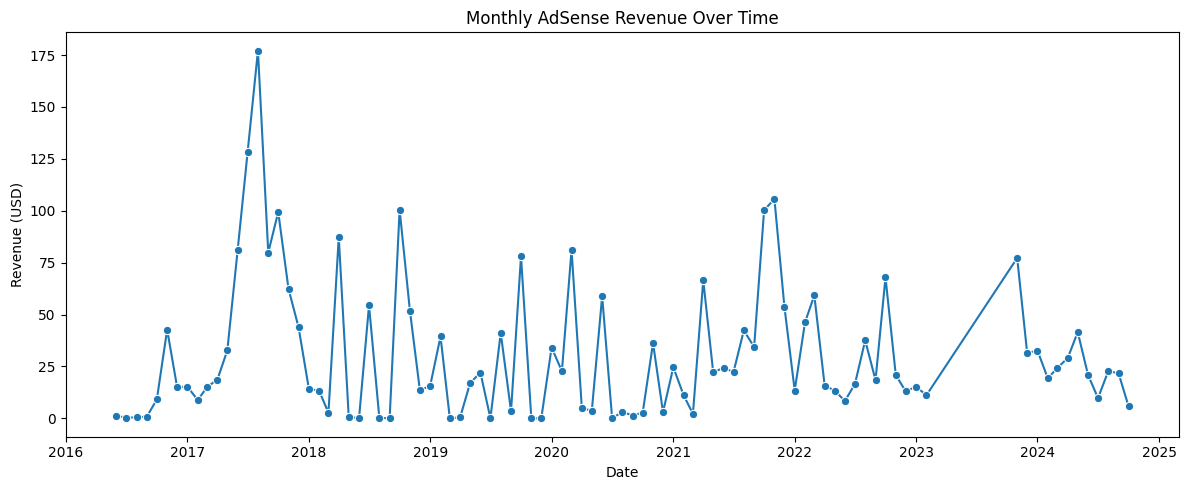

In [11]:
monthly_revenue = df.groupby(['Year', 'Month'])['Estimated AdSense Revenue (USD)'].sum().reset_index()
monthly_revenue['Period'] = pd.to_datetime(monthly_revenue[['Year', 'Month']].assign(DAY=1))

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_revenue, x='Period', y='Estimated AdSense Revenue (USD)', marker='o')
plt.title('Monthly AdSense Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue (USD)')
plt.tight_layout()
plt.show()

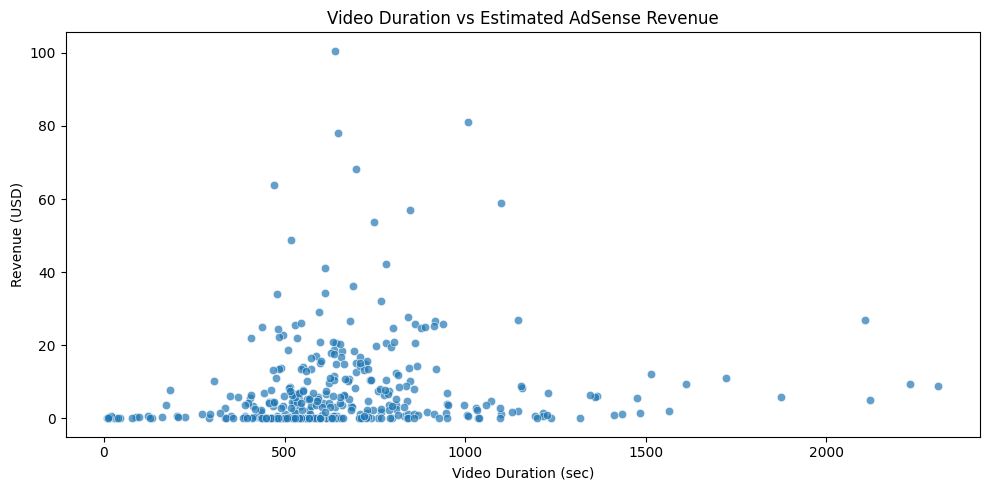

In [12]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Video Duration', y='Estimated AdSense Revenue (USD)', data=df, alpha=0.7)
plt.title('Video Duration vs Estimated AdSense Revenue')
plt.xlabel('Video Duration (sec)')
plt.ylabel('Revenue (USD)')
plt.tight_layout()
plt.show()

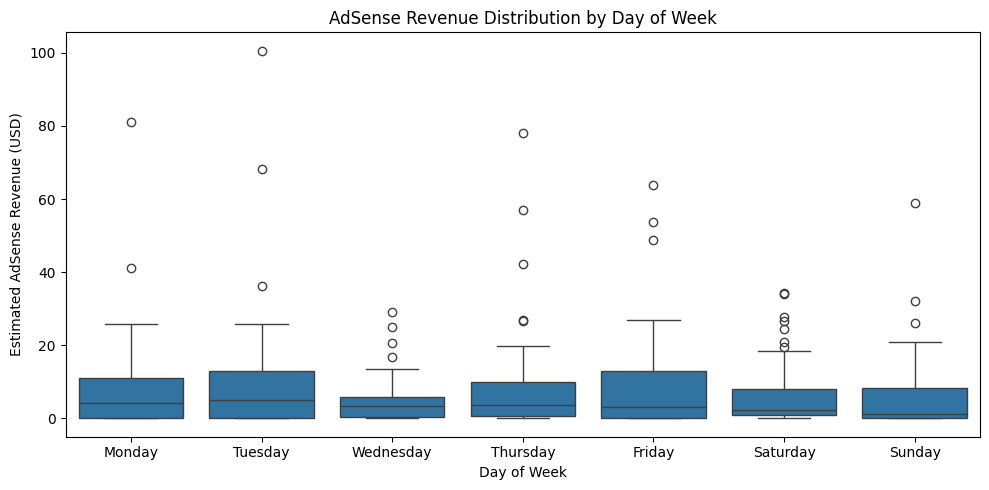

In [13]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10, 5))
sns.boxplot(x='Day of Week', y='Estimated AdSense Revenue (USD)', data=df, order=day_order)
plt.title('AdSense Revenue Distribution by Day of Week')
plt.tight_layout()
plt.show()

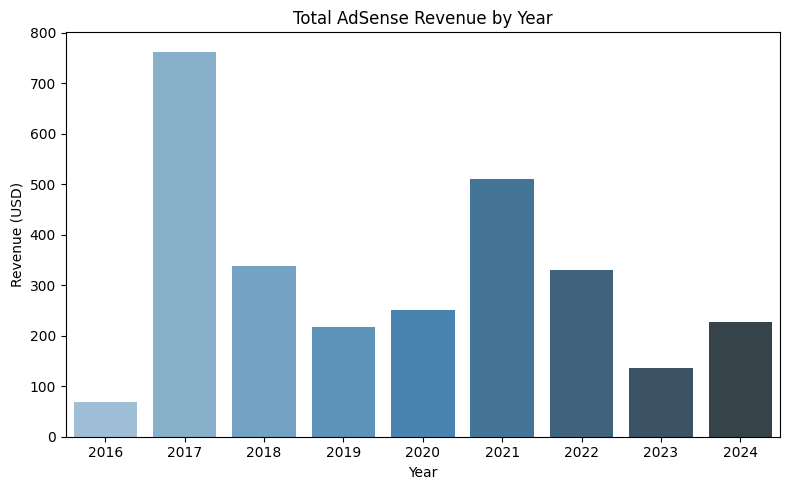

In [14]:
revenue_by_year = df.groupby('Year')['Estimated AdSense Revenue (USD)'].sum()

plt.figure(figsize=(8, 5))
sns.barplot(x=revenue_by_year.index, y=revenue_by_year.values, palette='Blues_d')
plt.title('Total AdSense Revenue by Year')
plt.xlabel('Year')
plt.ylabel('Revenue (USD)')
plt.tight_layout()
plt.show()

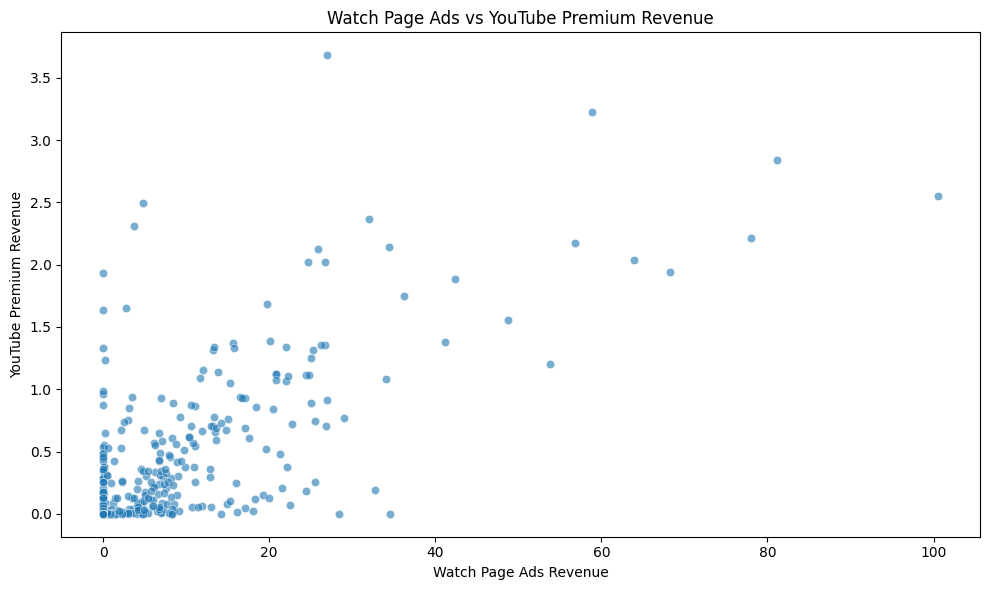

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Watch Page Ads Revenue (USD)', y='YouTube Premium (USD)', data=df, alpha=0.6)
plt.title('Watch Page Ads vs YouTube Premium Revenue')
plt.xlabel('Watch Page Ads Revenue')
plt.ylabel('YouTube Premium Revenue')
plt.tight_layout()
plt.show()

#Correlation Analysis

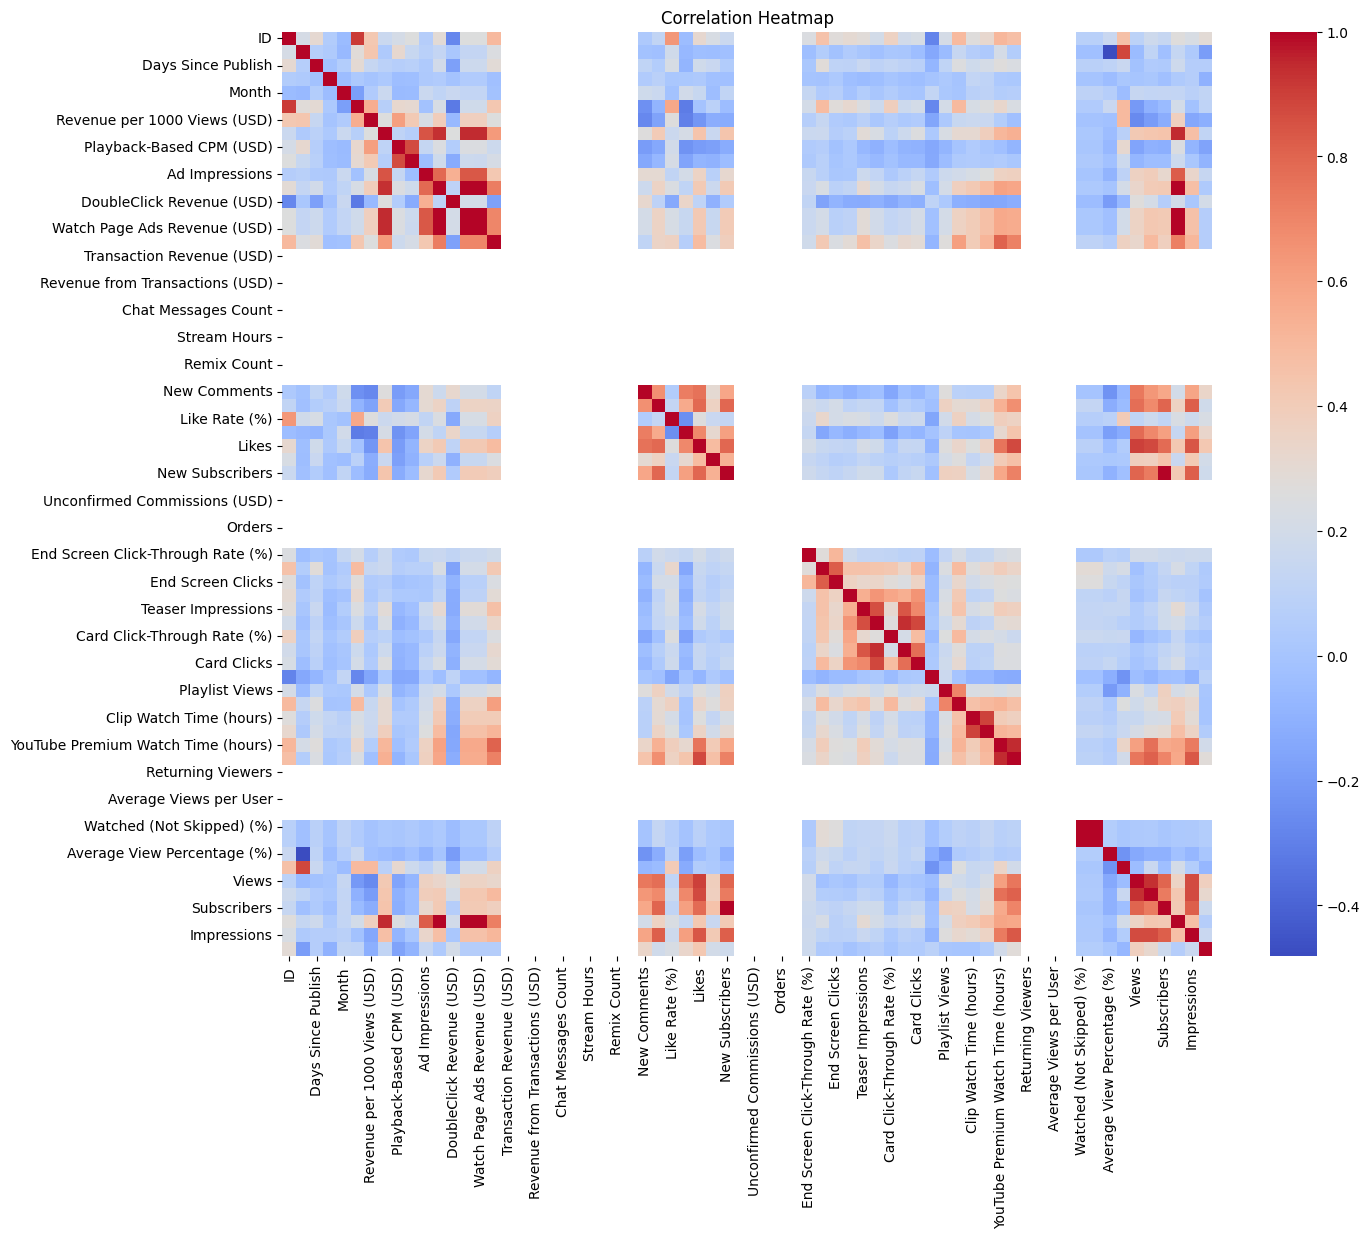

In [8]:
numeric_df = df.select_dtypes(include=[np.number])

corr = numeric_df.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr, cmap='coolwarm', annot=False, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Predictive Modeling

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error

# Define features and target variable
X = numeric_df.drop(columns=['Estimated Revenue (USD)'])
y = numeric_df['Estimated Revenue (USD)']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=42)

# Initialize and train the model
model = RandomForestRegressor(n_estimators=100,
random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate the prediction accuracy
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse

np.float64(0.45593992214488205)